<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_12_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 12:  Bosques aleatorios



Los arboles de desicion se ajustan muy bien a los datos de entrenamiento, sin embargo no permiten generalización. El overfiting es la caracteristica mas importante. Para dar solucion, se propone el algoritmo de random foreset basado en dos caracteristicas:

# 1. Se enetrenan varios árboles con diferentes subconjuntos del dataset original. Para ello se emplea bootstraping dentro de los datos del dataset inicial.


Dado un dataset con las siguientes caracteristicas:


|index|$y^{}$          |X1  |X2 |X3 |X4 |
|-|----------|-----|-----|-----|-----|
|1| |$y^{(1)}$ |$X_1^{1}$|$X_2^{1}$|$X_3^{1}$|$X_4^{1}$|
|2||$y^{(2)}$ |$X_1^{2}$|$X_2^{2}$|$X_3^{2}$|$X_4^{2}$|
|3||$y^{(3)}$ |$X_1^{3}$|$X_2^{3}$|$X_3^{3}$|$X_4^{3}$|
|4||$y^{(4)}$ |$X_1^{4}$|$X_2^{4}$|$X_3^{4}$|$X_4^{4}$|


Podemos definir como un hyperparametro el número de arboles, y también los datos que ingresan a cada árbol, para ello emplearemos la tecnica de [bootstraping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics).


El botstrapping es una técnica de muestreo con reposición que se realiza para cada árbol, asi si se tienen 10 árboles, el muestre con reposicion  para los indices puede ser como sigue:
```

In: np.random.randint(0, 4, (10,4))

  
Out: array([[1, 0, 3, 3],
       [2, 1, 2, 0],
       [2, 3, 3, 3],
       [0, 2, 2, 3],
       [2, 0, 3, 3],
       [1, 1, 2, 0],
       [2, 2, 1, 2],
       [3, 0, 1, 0],
       [3, 1, 0, 2],
       [2, 0, 2, 0]])

```

Lo anterior quiere decir que el conjunto de datos del árbol 1, puede ser entrenado con las  X1, X2, X3, X4 con los datos de entrenamiento 2, 1, 2, 0


Cada fila del anterior array es usado como input para entrenar cada arbol, notese que los valores se puden repetir para entrenar el árbol i-esimo.


- Para cada nodo de todos los arboles se selecciona un número aleatorio de características, hasta cosntruir el árbol completo.


Al final se tendran un conjunto de arboles de desición sobre los cuales se aplicará agregación, es decir, cuando se pasa un nuevo dato de entrenamiento los arboles realizan la clasificación y se toma el valor elegido por la mayoria de los arboles



bagging = Agregation + bootstraping


Random forest permite seleccionar las caracteristicas más importantes


La estategia para optimizar los bosques pueden ser elegidos como sigue:

Fijar el numero de caracteristicas y el criterio de parada.

1. Determinar el error como función del número de árboles.

2. Definido el número de árboles y calculamos el error como función del numero de caracteristicas.

3. Con el numero de arboles fijo y el numero de caracteristicas, se optmiza el criterio de parada, (numero minimo de datos de una hoja)




REF: https://www.youtube.com/watch?v=3pa0vtW64Ic&ab_channel=CodificandoBits
https://en.wikipedia.org/wiki/Bootstrap_aggregating

ref: http://www.cs.cmu.edu/~qyj/papersA08/11-rfbook.pdf

ref : https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=4,
                           n_informative=2, n_redundant=0,
                           random_state=0, shuffle=False)

clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

print(clf.predict([[0, 0, 0, 0]]))

[1]


Laboratorio:

1. Cargar load digitis
```
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[95])
plt.show()
```

2. Aplicar random foreset usando sklearn para clasificar el dataset

(1797, 64)


<Figure size 640x480 with 0 Axes>

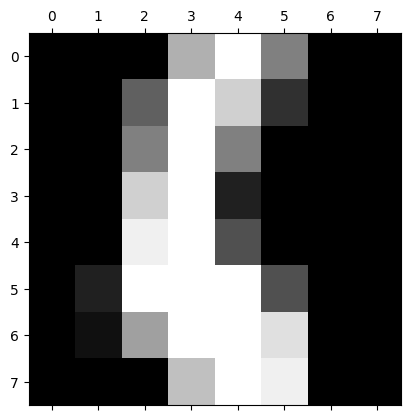

In [4]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[95])
plt.show()

### Aplicar Random Forest para clasificar el dataset `digits`

Primero, dividiremos el dataset en conjuntos de entrenamiento y prueba. Luego, entrenaremos un modelo `RandomForestClassifier` y evaluaremos su precisión.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

# Cargar el dataset digits (asegurando que esté disponible)
digits = load_digits()

# Obtener los datos y las etiquetas del dataset digits
X_digits = digits.data
y_digits = digits.target

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)

# Inicializar y entrenar el clasificador Random Forest
# Puedes ajustar los hiperparámetros como n_estimators, max_depth, etc.
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los núcleos de CPU
rf_clf.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred = rf_clf.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo Random Forest en el conjunto de prueba: {accuracy:.4f}")

Precisión del modelo Random Forest en el conjunto de prueba: 0.9722


In [7]:
# Re-executing cell ede6ebe7 after fix
# (This cell is a placeholder for re-execution, the content is already in ede6ebe7)
# This execution should now define 'digits' and 'rf_clf'


Para una evaluación más robusta, también podemos usar validación cruzada:

In [9]:
from sklearn.model_selection import cross_val_score

# Realizar validación cruzada con 5 folds
cv_scores = cross_val_score(rf_clf, X_digits, y_digits, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Puntuaciones de validación cruzada: {cv_scores}")
print(f"Precisión promedio de validación cruzada: {cv_scores.mean():.4f}")
print(f"Desviación estándar de la precisión de validación cruzada: {cv_scores.std():.4f}")

Puntuaciones de validación cruzada: [0.93055556 0.91111111 0.95821727 0.96935933 0.9275766 ]
Precisión promedio de validación cruzada: 0.9394
Desviación estándar de la precisión de validación cruzada: 0.0213


### Optimización de Hiperparámetros para el dataset `digits` con GridSearchCV

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definir la cuadrícula de parámetros a buscar
param_grid_digits = [
    {'n_estimators': [50, 100, 150], 'max_features': [8, 16, 32]},
    {'bootstrap': [False], 'n_estimators': [50, 100], 'max_features': [8, 16]},
]

# Inicializar un RandomForestClassifier (puedes usar el mismo rf_clf o uno nuevo)
forest_clf_digits = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Iniciando GridSearchCV para el dataset 'digits' (esto puede tardar un tiempo)...")
# Configurar GridSearchCV
grid_search_digits = GridSearchCV(forest_clf_digits, param_grid_digits, cv=5,
                                 scoring='accuracy', return_train_score=True, n_jobs=-1)

# Ejecutar la búsqueda en cuadrícula en los datos completos de digits
grid_search_digits.fit(X_digits, y_digits)

print(f"Mejor puntuación de GridSearchCV para digits: {grid_search_digits.best_score_:.4f}")
print(f"Mejores hiperparámetros encontrados para digits: {grid_search_digits.best_params_}")

# Opcional: Evaluar el mejor modelo en el conjunto de prueba original (si X_test y y_test están definidos)
# best_model_digits = grid_search_digits.best_estimator_
# y_pred_best = best_model_digits.predict(X_test)
# accuracy_best = accuracy_score(y_test, y_pred_best)
# print(f"Precisión del mejor modelo en el conjunto de prueba: {accuracy_best:.4f}")

Iniciando GridSearchCV para el dataset 'digits' (esto puede tardar un tiempo)...
Mejor puntuación de GridSearchCV para digits: 0.9416
Mejores hiperparámetros encontrados para digits: {'bootstrap': False, 'max_features': 8, 'n_estimators': 100}
